## App Review Sentiment Analysis

App review Sentiment Analysis means evaluating and understanding the sentiment expressed in user reviews of mobile applications.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\singh\OneDrive\Desktop\Python\Data\linkedin-reviews - linkedin-reviews.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 702 entries, 0 to 701
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  702 non-null    object
 1   Rating  702 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 11.1+ KB


### Plotting the Distribution of ratings

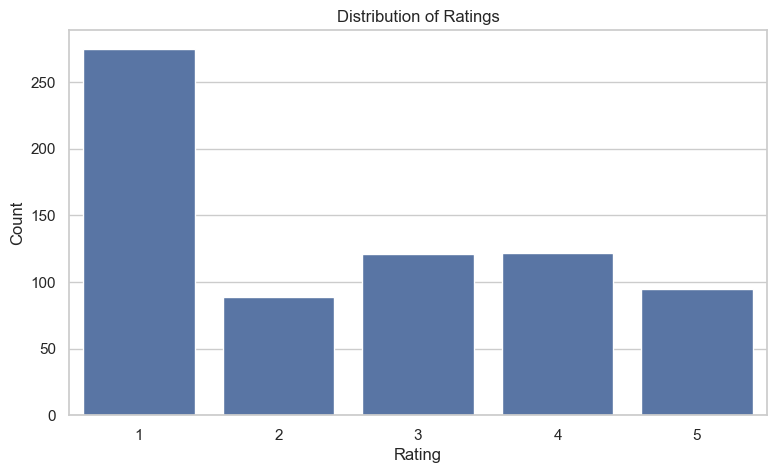

In [3]:
sns.set(style = "whitegrid")
plt.figure(figsize = (9,5))
sns.countplot(data = df, x = 'Rating')
plt.title('Distribution of Ratings')
plt.xlabel("Rating")
plt.ylabel('Count')
plt.show()

### Adding Sentiment Labels in the data

We will use textblob library.

Textblob provides a polarity scores raning from -1(very negative) to 1(very positive) for a given text. We can use this score to classify each review's sentiment as positive, negative and neutral.

In [ ]:
# !pip install textblob

   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB ? eta -:--:--
   ---------------- ----------------------- 262.1/624.3 kB 


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
from textblob import TextBlob

In [6]:
def textblob_sentiment_analysis(review):
    sentiment = TextBlob(review).sentiment
    if sentiment.polarity > 0.1:
        return "Positive"
    elif sentiment.polarity < -0.1:
        return "Negative"
    else:
        return "Neutral"

In [7]:
df['Sentiment'] = df['Review'].apply(textblob_sentiment_analysis)

In [4]:
df.sample(10)

,Review,Rating
2,Slow and it tries to upload your contacts with...,1
396,Would be great if i could update/edit my profi...,3
339,Crashes allot,1
466,So unbelievable slow! It's actually faster on ...,1
11,Piece of s**t app. Really? You want people to ...,1
428,"Great, I like it better on my phone than on my...",4
28,My phone crashed on first run but after that i...,3
223,Have to enter id and pass all the time?,1
481,Rubbish. Won't authenticate. Uninstalled.,1
594,Would give it 5 stars if I could update my pro...,4


## Analyzing App Reviews Sentiments

In [10]:
sentiment_distribution = df['Sentiment'].value_counts()
sentiment_distribution

Sentiment
Neutral     300
Positive    295
Negative    107
Name: count, dtype: int64

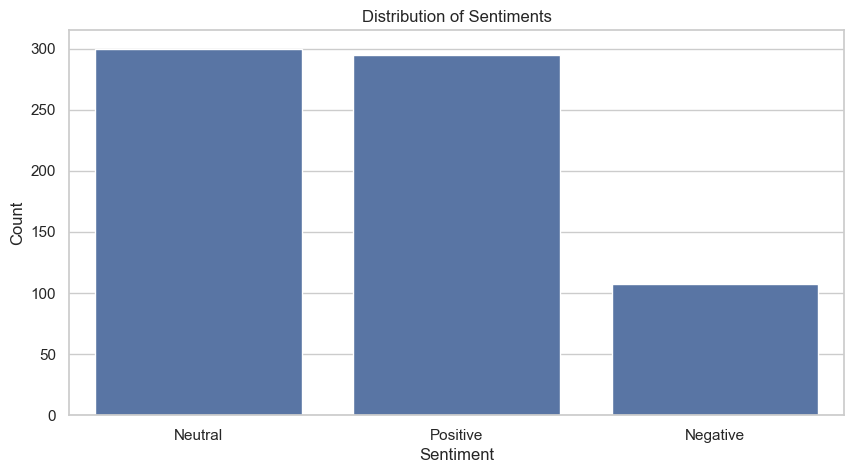

In [11]:
plt.figure(figsize= (10,5))
sns.barplot(x = sentiment_distribution.index,
            y = sentiment_distribution.values)
plt.title("Distribution of Sentiments")
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

## So, we can see althrough the app has low ratings, still the reviewers don't use many negative words in the reviews for the app.

Next, we'll explore the relationship between the sentiments and the ratings. This analysis can help us understand whether there is a correlation between the sentiments of the text and numerical ratings.

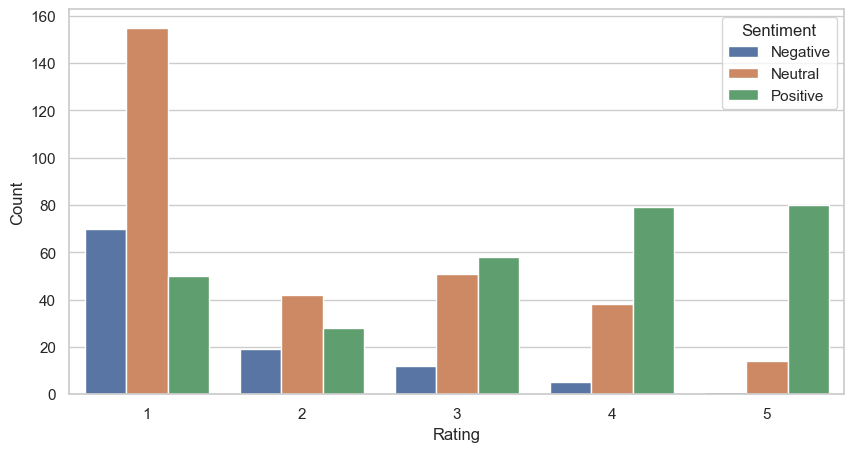

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, 
              x = 'Rating', 
              hue = 'Sentiment')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.legend(title = 'Sentiment')
plt.show()

## Summary

App Review Sentiment Analysis is a valuable tool for app developers and business to understand user feedback, prioritize feature updates and maintain a positive user community. It involves using data analysis techniques to determine whether the sentiments in these reviews are positive, negative or neutral.